# Predicting Customer Churn for a Subscription Streaming Service

## Business Problem

Subscription-based streaming platforms depend heavily on customer retention.
Customer churn happens when existing customers cancel their subscription.

Losing customers directly affects:
- Revenue
- Customer Lifetime Value (CLV)
- Business growth

The objective of this project is to build a Machine Learning system that predicts whether a customer is likely to churn based on their subscription behavior, billing details, and service usage patterns.

Early churn prediction allows marketing teams to:
- Identify high-risk customers
- Provide personalized offers
- Improve customer satisfaction
- Reduce revenue loss


## Dataset Information

Dataset Used:
Telco Customer Churn Dataset (Kaggle)

The dataset contains customer information including:

1. Customer Demographics
- Gender
- Senior Citizen
- Partner
- Dependents

2. Subscription Information
- Contract type
- Internet service
- Streaming services
- Tenure

3. Billing Information
- Monthly Charges
- Total Charges
- Payment Method

Target Variable:

Churn:
- Yes → Customer cancelled subscription
- No → Customer continued subscription


Machine Learning Task:
Binary Classification Problem

In [14]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# ML preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Cross validation and tuning
from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Dataset Loading

The Telco Customer Churn dataset is loaded using Pandas.
Initial inspection helps understand:

- Number of rows
- Number of columns
- Feature types

In [15]:
df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
# Dataset dimensions

print(
    "Rows:",
    df.shape[0]
)

print(
    "Columns:",
    df.shape[1]
)

Rows: 7043
Columns: 21


In [17]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Missing values can negatively impact model learning.
Before training ML models, missing values must be detected and handled.

In [18]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [19]:
duplicates = df.duplicated().sum()

print(
    "Duplicate Records:",
    duplicates
)

Duplicate Records: 0


In [20]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

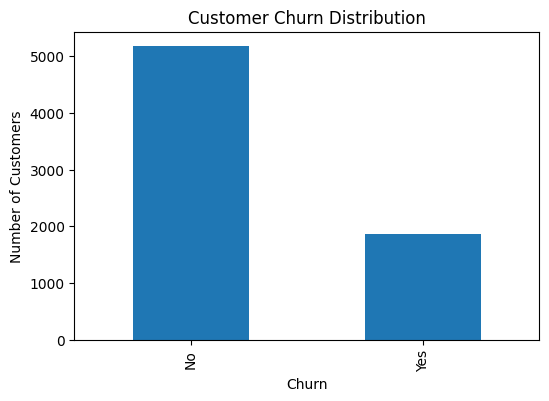

In [21]:
plt.figure(figsize=(6,4))

df["Churn"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Customer Churn Distribution"
)

plt.xlabel(
    "Churn"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

Observation:

The number of non-churn customers is higher compared to churn customers.

This indicates slight class imbalance.

Accuracy alone may not be sufficient, therefore Precision, Recall and F1-score will also be considered.

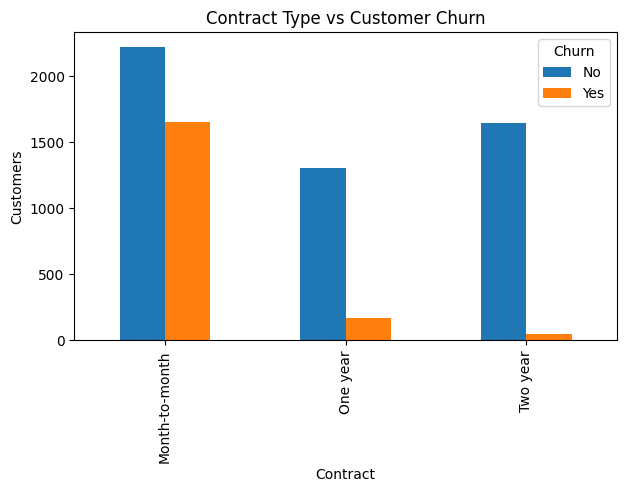

In [22]:
pd.crosstab(
    df["Contract"],
    df["Churn"]
).plot(
    kind="bar",
    figsize=(7,4)
)


plt.title(
    "Contract Type vs Customer Churn"
)

plt.ylabel(
    "Customers"
)

plt.show()

Customers with month-to-month contracts show higher churn tendency.

Long-term contracts help retain customers.

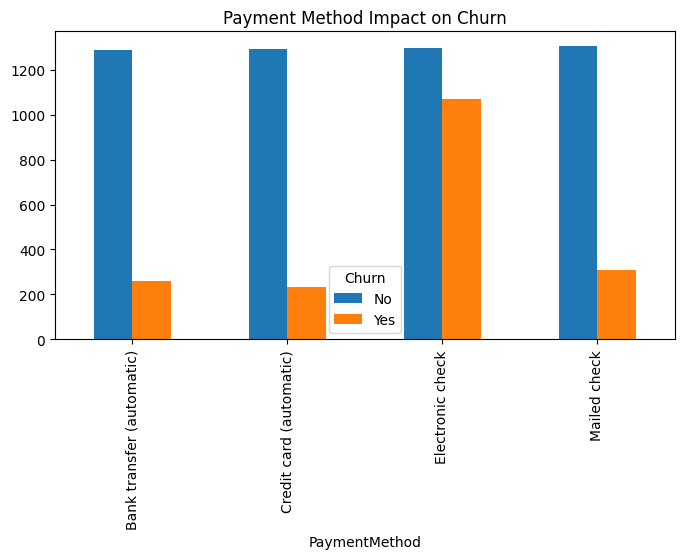

In [23]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
).plot(
    kind="bar",
    figsize=(8,4)
)


plt.title(
    "Payment Method Impact on Churn"
)

plt.show()

In [24]:
temp = df.copy()

temp["Churn"] = temp["Churn"].map(
    {
        "Yes":1,
        "No":0
    }
)

numeric_data = temp.select_dtypes(
    include=np.number
)

numeric_data.corr()

,SeniorCitizen,tenure,MonthlyCharges,Churn
SeniorCitizen,1.000000,0.016567,0.220173,0.150889
tenure,0.016567,1.000000,0.247900,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.193356
Churn,0.150889,-0.352229,0.193356,1.000000


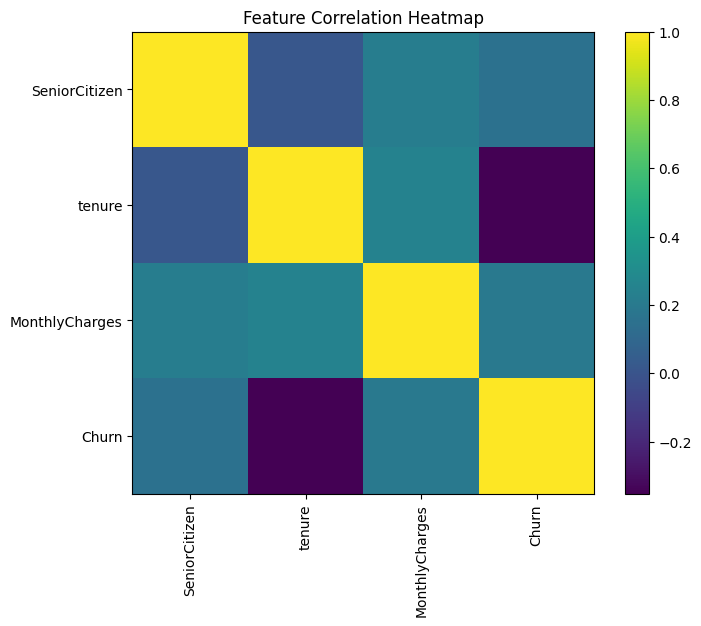

In [25]:
corr = numeric_data.corr()


plt.figure(figsize=(8,6))

plt.imshow(
    corr
)

plt.colorbar()

plt.xticks(
    range(len(corr)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr)),
    corr.columns
)


plt.title(
    "Feature Correlation Heatmap"
)

plt.show()

EDA Observations:

1. Month-to-month customers have higher churn probability.

2. Contract duration and customer tenure strongly affect retention.

3. Billing features influence customer cancellation behavior.

4. Feature engineering and selection can improve model efficiency.